In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_final = pd.read_csv("/content/drive/MyDrive/UIDAI_DATA/UIDAI_DF.csv")

In [ ]:
df_final.head()

,date,state,district,age_0_5,age_5_17,age_18_greater,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_
0,01-04-2025,Assam,Bongaigaon,221,87,61,4512,1135,348,4007
1,01-04-2025,Bihar,Bhagalpur,678,534,26,14317,10270,930,4372
2,01-04-2025,Chandigarh,Chandigarh,86,21,10,4587,3334,3917,10968
3,01-04-2025,Chhattisgarh,Durg,336,38,10,3606,15585,1119,4996
4,01-04-2025,Chhattisgarh,Raipur,299,12,11,3770,15413,933,9415


In [ ]:
df_final


,date,state,district,age_0_5,age_5_17,age_18_greater,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_
0,01-04-2025,Assam,Bongaigaon,221,87,61,4512,1135,348,4007
1,01-04-2025,Bihar,Bhagalpur,678,534,26,14317,10270,930,4372
2,01-04-2025,Chandigarh,Chandigarh,86,21,10,4587,3334,3917,10968
3,01-04-2025,Chhattisgarh,Durg,336,38,10,3606,15585,1119,4996
4,01-04-2025,Chhattisgarh,Raipur,299,12,11,3770,15413,933,9415
...,...,...,...,...,...,...,...,...,...,...
50054,31-10-2025,West Bengal,South 24 Parganas,581,221,0,768,1479,525,9079
50055,31-10-2025,West Bengal,South Dinajpur,7,2,0,4,16,4,230
50056,31-10-2025,West Bengal,South Twenty Four Parganas,65,24,1,43,330,19,1432
50057,31-10-2025,West Bengal,Uttar Dinajpur,321,119,3,199,568,209,5799


**Feature Engineering (Core Insight Layer)**

In [ ]:
df_final['total_enrolments'] = (
    df_final['age_0_5'] +
    df_final['age_5_17'] +
    df_final['age_18_greater']
)

df_final['total_updates'] = (
    df_final['bio_age_5_17'] +
    df_final['bio_age_17_'] +
    df_final['demo_age_5_17'] +
    df_final['demo_age_17_']
)


**Update-to-Enrolment Pressure Ratio**

High ratio → Aadhaar system maturity + correction load

Low ratio → expansion phase / new coverage

In [ ]:
df_final['update_enrolment_ratio'] = (
    df_final['total_updates'] /
    (df_final['total_enrolments'] + 1)  # avoid divide by zero
)


Biometric vs Demographic Update Split

In [ ]:
df_final['bio_updates'] = (
    df_final['bio_age_5_17'] +
    df_final['bio_age_17_']
)

df_final['demo_updates'] = (
    df_final['demo_age_5_17'] +
    df_final['demo_age_17_']
)

df_final['bio_share'] = df_final['bio_updates'] / (df_final['total_updates'] + 1)
df_final['demo_share'] = df_final['demo_updates'] / (df_final['total_updates'] + 1)


In [ ]:
df_final

,date,state,district,age_0_5,age_5_17,age_18_greater,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,total_enrolments,total_updates,update_enrolment_ratio,bio_updates,demo_updates,bio_share,demo_share
0,01-04-2025,Assam,Bongaigaon,221,87,61,4512,1135,348,4007,369,10002,27.032432,5647,4355,0.564531,0.435369
1,01-04-2025,Bihar,Bhagalpur,678,534,26,14317,10270,930,4372,1238,29889,24.123487,24587,5302,0.822583,0.177384
2,01-04-2025,Chandigarh,Chandigarh,86,21,10,4587,3334,3917,10968,117,22806,193.271186,7921,14885,0.347306,0.652651
3,01-04-2025,Chhattisgarh,Durg,336,38,10,3606,15585,1119,4996,384,25306,65.729870,19191,6115,0.758328,0.241633
4,01-04-2025,Chhattisgarh,Raipur,299,12,11,3770,15413,933,9415,322,29531,91.427245,19183,10348,0.649567,0.350400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50054,31-10-2025,West Bengal,South 24 Parganas,581,221,0,768,1479,525,9079,802,11851,14.758406,2247,9604,0.189588,0.810327
50055,31-10-2025,West Bengal,South Dinajpur,7,2,0,4,16,4,230,9,254,25.400000,20,234,0.078431,0.917647
50056,31-10-2025,West Bengal,South Twenty Four Parganas,65,24,1,43,330,19,1432,90,1824,20.043956,373,1451,0.204384,0.795068
50057,31-10-2025,West Bengal,Uttar Dinajpur,321,119,3,199,568,209,5799,443,6775,15.259009,767,6008,0.113194,0.886659



Calculate and visualize the average update-to-enrolment ratio state-wise and district-wise, highlighting top and bottom performers in a bar plot, and summarize key insights.

In [ ]:
state_ratio = df_final.groupby('state')['update_enrolment_ratio'].mean().sort_values(ascending=False)
print("State-wise Update-Enrolment Ratio (sorted descending):\n", state_ratio.head(10))

State-wise Update-Enrolment Ratio (sorted descending):
 state
Maharashtra       60.005702
Manipur           46.435403
Chhattisgarh      27.101024
Goa               26.169539
Andhra Pradesh    25.830074
Punjab            23.555040
Tamil Nadu        23.133044
Telangana         21.913304
West Bengal       21.051214
Chandigarh        20.922987
Name: update_enrolment_ratio, dtype: float64


In [ ]:
district_ratio = df_final.groupby(['state', 'district'])['update_enrolment_ratio'].mean().sort_values(ascending=False)
print("District-wise Update-Enrolment Ratio (sorted descending):\n", district_ratio.head(10))

District-wise Update-Enrolment Ratio (sorted descending):
 state        district   
Maharashtra  Ahmednagar     137.616398
             Nashik         125.794690
             Nanded         120.221153
Manipur      Thoubal         98.113009
Maharashtra  Ahilyanagar     93.000000
Manipur      Imphal West     88.981160
Maharashtra  Solapur         87.992162
             Yavatmal        87.291136
             Parbhani        86.192707
             Washim          85.960928
Name: update_enrolment_ratio, dtype: float64


## Visualize Top/Bottom State-wise Update-Enrolment Ratio

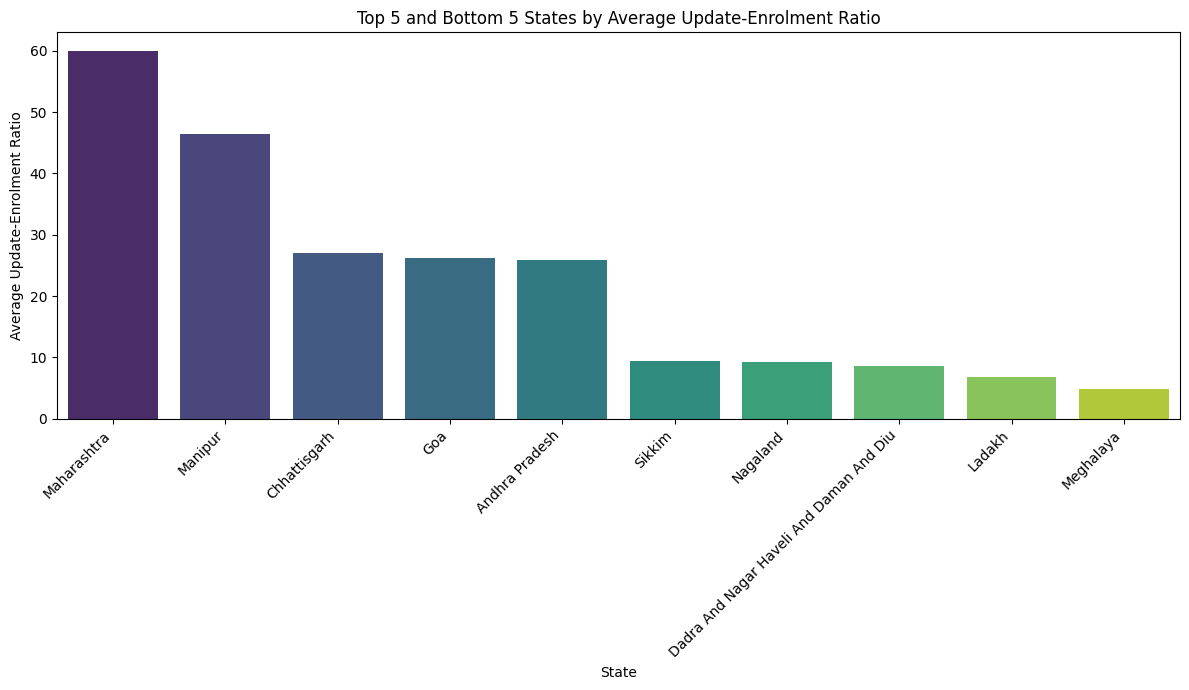

Bar plot showing top 5 and bottom 5 states by average update-enrolment ratio has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 5 and bottom 5 states
top_5_states = state_ratio.head(5)
bottom_5_states = state_ratio.tail(5)

# Combine for plotting
combined_states = pd.concat([top_5_states, bottom_5_states])

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(x=combined_states.index, y=combined_states.values, hue=combined_states.index, palette='viridis', legend=False)
plt.title('Top 5 and Bottom 5 States by Average Update-Enrolment Ratio')
plt.xlabel('State')
plt.ylabel('Average Update-Enrolment Ratio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Bar plot showing top 5 and bottom 5 states by average update-enrolment ratio has been generated.")

## Key Insights from State-wise Update-Enrolment Ratio Visualization

- **High Ratio States (e.g., Maharashtra, Manipur)**: These states exhibit a significantly higher average update-enrolment ratio. This could indicate a mature Aadhaar system with a large existing base of enrollees, leading to a higher proportion of activities being updates rather than new enrolments. It might also suggest a greater need or compliance for demographic and biometric updates, possibly due to policy enforcement or an older demographic profile of enrollees requiring frequent biometric updates.

- **Low Ratio States (e.g., Meghalaya, Ladakh)**: States like Meghalaya and Ladakh show very low update-enrolment ratios. This could point to regions where Aadhaar enrolment is still in its expansion phase, with a higher number of new enrolments compared to updates. Alternatively, it might suggest lower awareness, accessibility, or compliance for updates in these regions, or a younger demographic profile that requires fewer biometric updates.

- **Disparity in Ratios**: The wide disparity between the highest (Maharashtra) and lowest (Meghalaya) ratios highlights regional differences in Aadhaar penetration, usage patterns, and the lifecycle stage of the enrolment process. A high ratio might also suggest a higher load on update infrastructure, while a low ratio could indicate potential for further enrolment drives.

## Visualize Top/Bottom District-wise Update-Enrolment Ratio

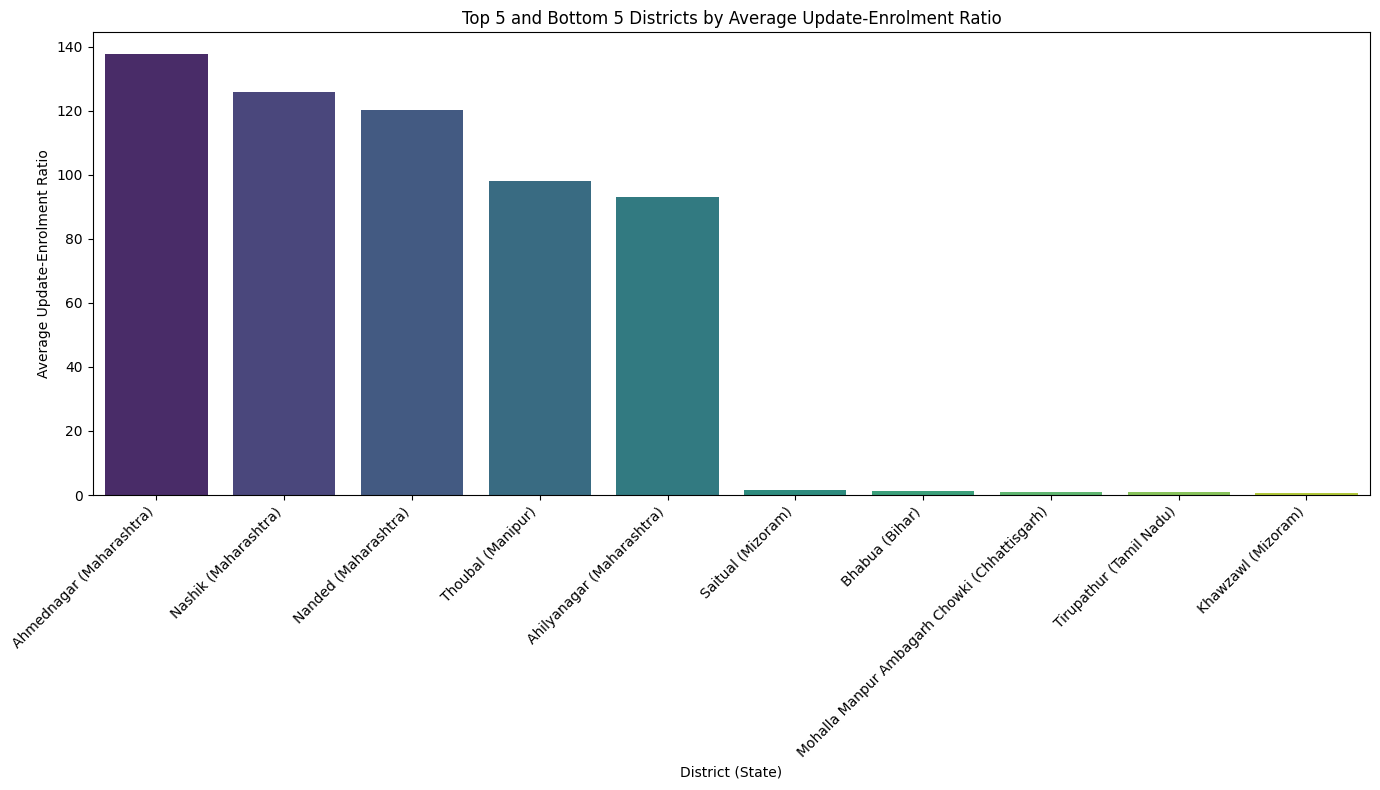

Bar plot showing top 5 and bottom 5 districts by average update-enrolment ratio has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 5 and bottom 5 districts
top_5_districts = district_ratio.head(5)
bottom_5_districts = district_ratio.tail(5)

# Combine for plotting
combined_districts = pd.concat([top_5_districts, bottom_5_districts])

# Prepare labels for plotting (including state for clarity)
plot_labels = [f"{idx[1]} ({idx[0]})" for idx in combined_districts.index]

# Plotting
plt.figure(figsize=(14, 8))
sns.barplot(x=plot_labels, y=combined_districts.values, hue=plot_labels, palette='viridis', legend=False)
plt.title('Top 5 and Bottom 5 Districts by Average Update-Enrolment Ratio')
plt.xlabel('District (State)')
plt.ylabel('Average Update-Enrolment Ratio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Bar plot showing top 5 and bottom 5 districts by average update-enrolment ratio has been generated.")

## Key Insights from District-wise Update-Enrolment Ratio Visualization

-   **High Ratio Districts (e.g., Ahmednagar, Nashik in Maharashtra, Thoubal in Manipur)**: These districts show extremely high update-enrolment ratios, far exceeding the state averages. This could indicate localized factors such as intensive update campaigns, a very mature Aadhaar penetration with little room for new enrolments, or potentially data anomalies that lead to a disproportionately high number of updates relative to enrolments. These districts might represent areas with a high need for biometric updates (e.g., aging populations) or demographic corrections.

-   **Low Ratio Districts (e.g., Saitual and Khawzawl in Mizoram, Bhabua in Bihar)**: These districts exhibit very low update-enrolment ratios. Similar to low-ratio states, this suggests that Aadhaar enrolment in these specific districts might still be in an early expansion phase, with new enrolments forming the bulk of activity. It could also point to regions with lower awareness, accessibility, or less stringent update requirements, or a younger population demographic that necessitates fewer updates.

-   **Regional Patterns within States**: It's notable that some high-ratio districts (e.g., Ahmednagar, Nashik, Nanded) are all within Maharashtra, indicating a state-level trend towards a higher update-enrolment ratio that is amplified in certain districts. Conversely, low-ratio districts might show localized pockets where enrolment efforts are still primary.

-   **Significant Variation**: The vast difference between the highest and lowest district ratios highlights the granular differences in Aadhaar lifecycle stages and operational focus at the district level, even more pronounced than at the state level. This suggests that local conditions, demographics, and administrative priorities play a critical role in shaping enrolment and update patterns.

## Summary:


### Data Analysis Key Findings
*   The average `update_enrolment_ratio` varies significantly across states, with Maharashtra leading at approximately 60.01%, followed by Manipur at 46.44%.
*   The lowest state ratios are observed in states like Meghalaya and Ladakh, implying a focus on initial enrolments rather than updates.
*   At the district level, the highest `update_enrolment_ratio` was found in Ahmednagar (Maharashtra) at 137.62, which is substantially higher than any state average.
*   Conversely, districts such as Saitual and Khawzawl (Mizoram) show very low ratios, suggesting active new enrolment campaigns.
*   There is a clear regional pattern, with multiple top-performing districts located within high-performing states (e.g., Ahmednagar, Nashik, Nanded, Dhule all in Maharashtra).

### Insights or Next Steps
*   Further investigation into high-ratio areas (e.g., Ahmednagar, Maharashtra) could reveal best practices or specific demographic trends (e.g., aging population, high migration) that drive a greater need for updates, which could be replicated or addressed elsewhere.
*   For low-ratio areas (e.g., Meghalaya, Mizoram districts), targeted campaigns could be designed to boost initial Aadhaar enrolments, followed by awareness programs for future updates, to ensure comprehensive coverage and data accuracy.


**Maharashtra State Analysis**

In [ ]:
maharashtra_ratio = df_final[df_final['state']=='Maharashtra'].groupby('district')['update_enrolment_ratio'].mean().sort_values(ascending=False)
print("State-wise Update-Enrolment Ratio (sorted descending):\n", maharashtra_ratio.head(30))

State-wise Update-Enrolment Ratio (sorted descending):
 district
Ahmednagar                   137.616398
Nashik                       125.794690
Nanded                       120.221153
Ahilyanagar                   93.000000
Solapur                       87.992162
Yavatmal                      87.291136
Parbhani                      86.192707
Washim                        85.960928
Gadchiroli                    85.059853
Ratnagiri                     80.865263
Amravati                      77.497495
Chandrapur                    77.179911
Latur                         76.704190
Pune                          71.705472
Beed                          71.453262
Wardha                        69.623472
Sangli                        68.116719
Jalna                         67.689700
Bhandara                      64.162912
Dharashiv                     60.790071
Hingoli                       59.973165
Buldhana                      59.386789
Buldana                       57.152212
Gondiya        

/tmp/ipython-input-3144919834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


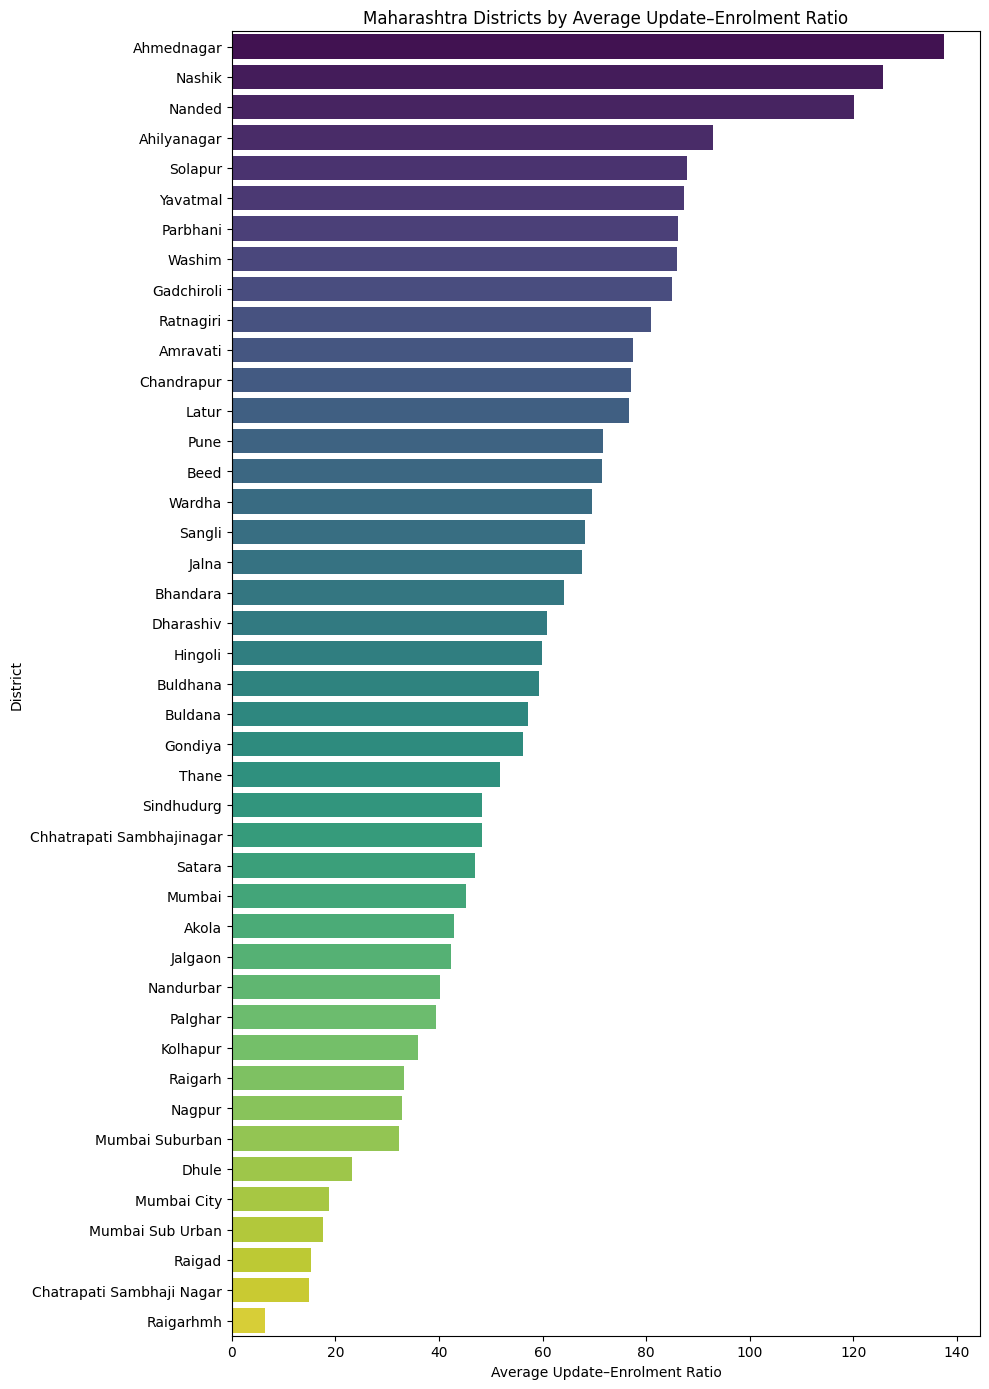

In [ ]:
plt.figure(figsize=(10, 14))

sns.barplot(
    y=maharashtra_ratio.index,          # districts on Y-axis
    x=maharashtra_ratio.values,         # ratio on X-axis
   palette='viridis', legend=False
)

plt.title('Maharashtra Districts by Average Update–Enrolment Ratio')
plt.xlabel('Average Update–Enrolment Ratio')
plt.ylabel('District')

plt.tight_layout()
plt.show()


**State-wise Bio and Demo Share**

In [ ]:
state_bio_share = df_final.groupby('state')['bio_share'].mean().sort_values(ascending=False)
state_demo_share = df_final.groupby('state')['demo_share'].mean().sort_values(ascending=False)

print("State-wise Average Bio Share (sorted descending):\n", state_bio_share.head(10))
print("\nState-wise Average Demo Share (sorted descending):\n", state_demo_share.head(10))

State-wise Average Bio Share (sorted descending):
 state
Dadra And Nagar Haveli         0.663755
Jammu And Kashmir              0.611421
Lakshadweep                    0.611065
Andaman And Nicobar Islands    0.607421
Puducherry                     0.598261
Himachal Pradesh               0.594243
Daman And Diu                  0.579563
Haryana                        0.571750
Maharashtra                    0.568727
Rajasthan                      0.568604
Name: bio_share, dtype: float64

State-wise Average Demo Share (sorted descending):
 state
Dadra And Nagar Haveli And Daman And Diu    0.730913
West Bengal                                 0.720527
Bihar                                       0.658744
Telangana                                   0.645352
Meghalaya                                   0.609911
Assam                                       0.600457
Sikkim                                      0.594165
Manipur                                     0.585098
Chandigarh                  

**District-wise Bio and Demo Share**


In [ ]:
district_bio_share = df_final.groupby(['state', 'district'])['bio_share'].mean().sort_values(ascending=False)
district_demo_share = df_final.groupby(['state', 'district'])['demo_share'].mean().sort_values(ascending=False)

print("District-wise Average Bio Share (sorted descending):\n", district_bio_share.head(10))
print("\nDistrict-wise Average Demo Share (sorted descending):\n", district_demo_share.head(10))

District-wise Average Bio Share (sorted descending):
 state              district                
Nagaland           Meluri                      0.856351
Chhattisgarh       Dantewada                   0.780530
Maharashtra        Nandurbar                   0.760900
                   Wardha                      0.735377
Madhya Pradesh     Hoshangabad                 0.731517
Jammu And Kashmir  Ramban                      0.727353
Madhya Pradesh     Burhanpur                   0.720275
                   Harda                       0.715735
Telangana          Medchal−Malkajgiri          0.712469
Chhattisgarh       Dakshin Bastar Dantewada    0.706975
Name: bio_share, dtype: float64

District-wise Average Demo Share (sorted descending):
 state         district                       
Maharashtra   Ahilyanagar                        0.979449
Karnataka     Bengaluru South                    0.913469
Chhattisgarh  Mohla Manpur Ambagarh Chouki       0.895682
              Manendragarh Chirmir

## Summary: Bio and Demo Shares

### Q&A
The key insights from the state-wise and district-wise `bio_share` and `demo_share` plots are:

*   **State-wise Bio Share Insights**:
    *   **Top Performers (Bio Share)**: States like Dadra and Nagar Haveli (0.66), Jammu and Kashmir (0.61), and Lakshadweep (0.61) show a higher proportion of biometric updates. This could imply a focus on ensuring the accuracy of biometric data, perhaps due to a relatively stable or aging population, or specific governmental initiatives.
    *   **Bottom Performers (Bio Share)**: States such as Dadra And Nagar Haveli And Daman And Diu (0.20), West Bengal (0.27), and Bihar (0.33) have significantly lower bio shares. This might suggest a greater emphasis on demographic updates or a younger population requiring fewer biometric updates.

*   **State-wise Demo Share Insights**:
    *   **Top Performers (Demo Share)**: Dadra And Nagar Haveli And Daman And Diu (0.73), West Bengal (0.72), and Bihar (0.66) exhibit the highest average demo shares. This indicates a higher proportion of updates related to demographic information (name, address, date of birth, etc.), possibly due to administrative corrections, migration, or changes in personal details.
    *   **Bottom Performers (Demo Share)**: States like Dadra And Nagar Haveli (0.33), Lakshadweep (0.36), and Andaman And Nicobar Islands (0.36) have the lowest demo shares, suggesting that a larger portion of their updates are biometric.

*   **District-wise Bio Share Insights**:
    *   **Top Performers (Bio Share)**: Districts like Meluri (Nagaland, 0.86), Dantewada (Chhattisgarh, 0.78), and Nandurbar (Maharashtra, 0.76) show extremely high bio shares. This could indicate localized efforts to update biometric records, a population segment that frequently requires biometric updates (e.g., due to age-related changes), or a very high initial enrolment saturation.
    *   **Bottom Performers (Bio Share)**: Ahilyanagar (Maharashtra, 0.015), Bengaluru South (Karnataka, 0.06), and Manendragarh Chirmiri Bharatpur (Chhattisgarh, 0.08) have very low bio shares. These districts likely prioritize demographic updates or are experiencing high rates of new enrolments or demographic changes.

*   **District-wise Demo Share Insights**:
    *   **Top Performers (Demo Share)**: Ahilyanagar (Maharashtra, 0.98), Bengaluru South (Karnataka, 0.91), and Mohla Manpur Ambagarh Chouki (Chhattisgarh, 0.90) exhibit exceptionally high demo shares. This points to significant demographic data corrections or updates in these areas, potentially driven by factors like urbanization, migration, or efforts to clean data records.
    *   **Bottom Performers (Demo Share)**: Meluri (Nagaland, 0.09), Dantewada (Chhattisgarh, 0.21), and Nandurbar (Maharashtra, 0.24) have very low demo shares. These districts demonstrate a strong emphasis on biometric updates, with demographic updates forming a smaller proportion of overall update activities.

### Data Analysis Key Findings
*   **Inverse Relationship**: Generally, there appears to be an inverse relationship between `bio_share` and `demo_share` at both state and district levels, meaning areas with high biometric updates tend to have lower demographic updates and vice-versa. This is expected as these are proportions of the total updates.
*   **Regional Specialization**: Some regions demonstrate clear specialization; for example, Dadra And Nagar Haveli is high in bio share but low in demo share (as a standalone territory), while Dadra And Nagar Haveli And Daman And Diu (combined territory) is high in demo share. Similarly, districts within states can show opposing trends (e.g., Ahilyanagar in Maharashtra with very high demo share, but Nandurbar and Wardha in Maharashtra showing high bio share).
*   **Extreme Local Variations**: District-level shares often show more extreme values than state-level averages, indicating highly localized factors influencing update types. For instance, Ahilyanagar (Maharashtra) has a demo share of nearly 98%, while Meluri (Nagaland) has a bio share of 86%.

### Insights or Next Steps
*   **Policy Implications**: Understanding these disparities can help policymakers in UIDAI tailor campaigns. For instance, in areas with high `demo_share`, focus could be on verifying demographic changes more rigorously, while in high `bio_share` areas, ensuring the efficiency of biometric capture and update processes would be crucial.
*   **Demographic Analysis**: Further analysis correlating `bio_share` and `demo_share` with demographic data (e.g., age distribution, migration patterns, literacy rates) for each state and district could provide deeper insights into the underlying reasons for these patterns.
*   **Operational Efficiency**: Areas with consistently high shares of one type of update might indicate bottlenecks or specific operational challenges that need to be addressed to balance the update types effectively.

**Analytical Questions**

**Q1. Which states/districts face the highest Aadhaar service pressure?**

In [ ]:
state_pressure = (
    df_final.groupby('state')['update_enrolment_ratio']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


In [ ]:
state_pressure

,update_enrolment_ratio
state,
Maharashtra,60.005702
Manipur,46.435403
Chhattisgarh,27.101024
Goa,26.169539
Andhra Pradesh,25.830074
Punjab,23.555040
Tamil Nadu,23.133044
Telangana,21.913304
West Bengal,21.051214


Insight Direction

High ratio states = high correction / migration / data churn

These need:

More centres

Mobile vans

Extended hours

📌 This is policy actionable.

**Q2. How does Aadhaar maturity differ across regions?**

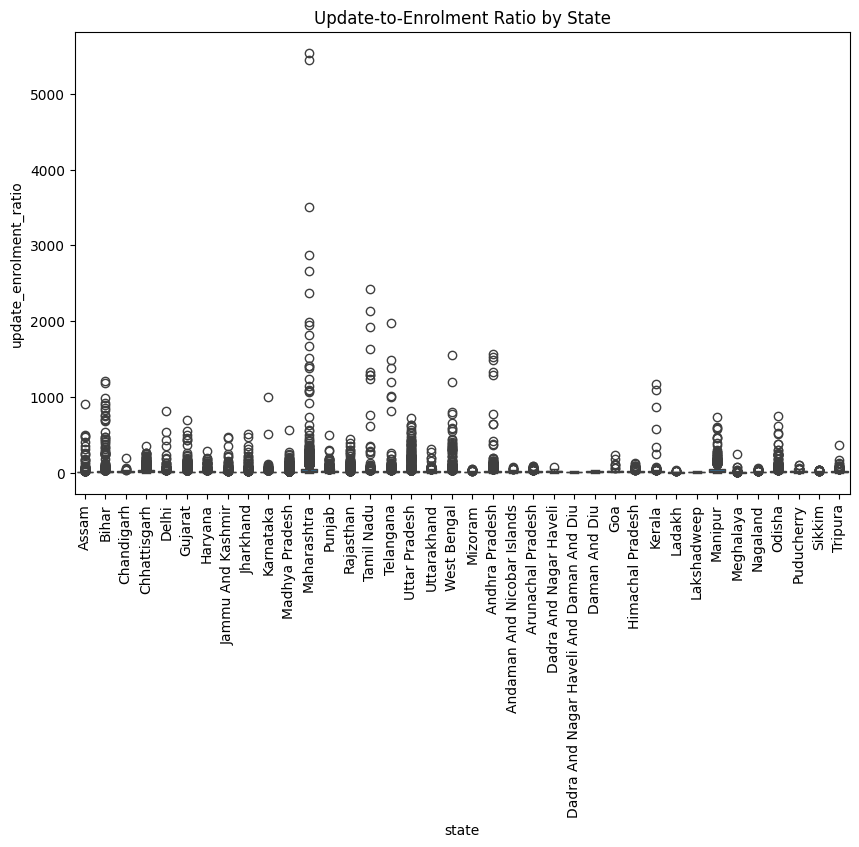

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_final,
    x='state',
    y='update_enrolment_ratio'
)
plt.xticks(rotation=90)
plt.title("Update-to-Enrolment Ratio by State")
plt.show()


In [ ]:
import geopandas as gpd

# Load the GeoJSON file into a GeoDataFrame
gdf_india = gpd.read_file('/content/drive/MyDrive/UIDAI_DATA/Indian_States_geojson.json')

In [ ]:
# Standardize state names in gdf_india to match state_ratio
gdf_india['NAME_1'] = gdf_india['NAME_1'].replace({
    'Dadra and Nagar Haveli': 'Dadra And Nagar Haveli',
    'Daman and Diu': 'Daman And Diu',
    'Andaman and Nicobar': 'Andaman And Nicobar Islands',
    'Arunanchal Pradesh': 'Arunachal Pradesh',
    'Jammu and Kashmir': 'Jammu And Kashmir',
    'Uttaranchal': 'Uttarakhand',
    'Orissa': 'Odisha',
    'Puducherry (Pondicherry)': 'Puducherry',
    'NCT of Delhi': 'Delhi',
    'Goa': 'Goa',
    'Chhattisgarh': 'Chhattisgarh',
    'Bihar': 'Bihar',
    'Assam': 'Assam',
    'Andhra Pradesh': 'Andhra Pradesh',
    'Gujarat': 'Gujarat',
    'Haryana': 'Haryana',
    'Himachal Pradesh': 'Himachal Pradesh',
    'Jharkhand': 'Jharkhand',
    'Karnataka': 'Karnataka',
    'Kerala': 'Kerala',
    'Madhya Pradesh': 'Madhya Pradesh',
    'Maharashtra': 'Maharashtra',
    'Manipur': 'Manipur',
    'Meghalaya': 'Meghalaya',
    'Mizoram': 'Mizoram',
    'Nagaland': 'Nagaland',
    'Punjab': 'Punjab',
    'Rajasthan': 'Rajasthan',
    'Sikkim': 'Sikkim',
    'Tamil Nadu': 'Tamil Nadu',
    'Telangana': 'Telangana',
    'Tripura': 'Tripura',
    'Uttar Pradesh': 'Uttar Pradesh',
    'West Bengal': 'West Bengal',
    'Ladakh': 'Ladakh',
    'Chandigarh': 'Chandigarh'
})

# Convert state_ratio to a DataFrame and reset index for merging
state_ratio_df = state_ratio.reset_index()
state_ratio_df.rename(columns={'index': 'state'}, inplace=True)

# Rename 'state' column in state_ratio_df to 'NAME_1' to match gdf_india for merging
state_ratio_df.rename(columns={'state': 'NAME_1'}, inplace=True)

# Merge gdf_india with state_ratio_df
# Use a left merge to keep all geometries from gdf_india and add update_enrolment_ratio
merged_gdf = gdf_india.merge(state_ratio_df, on='NAME_1', how='left')

print("Merged GeoDataFrame head:")

# Check for unmerged states
unmerged_states = merged_gdf[merged_gdf['update_enrolment_ratio'].isna()]['NAME_1'].unique()
if len(unmerged_states) > 0:
    print(f"\nStates in GeoDataFrame not found in state_ratio data: {unmerged_states}")

print("gdf_india and state_ratio merged into merged_gdf.")

Merged GeoDataFrame head:
gdf_india and state_ratio merged into merged_gdf.


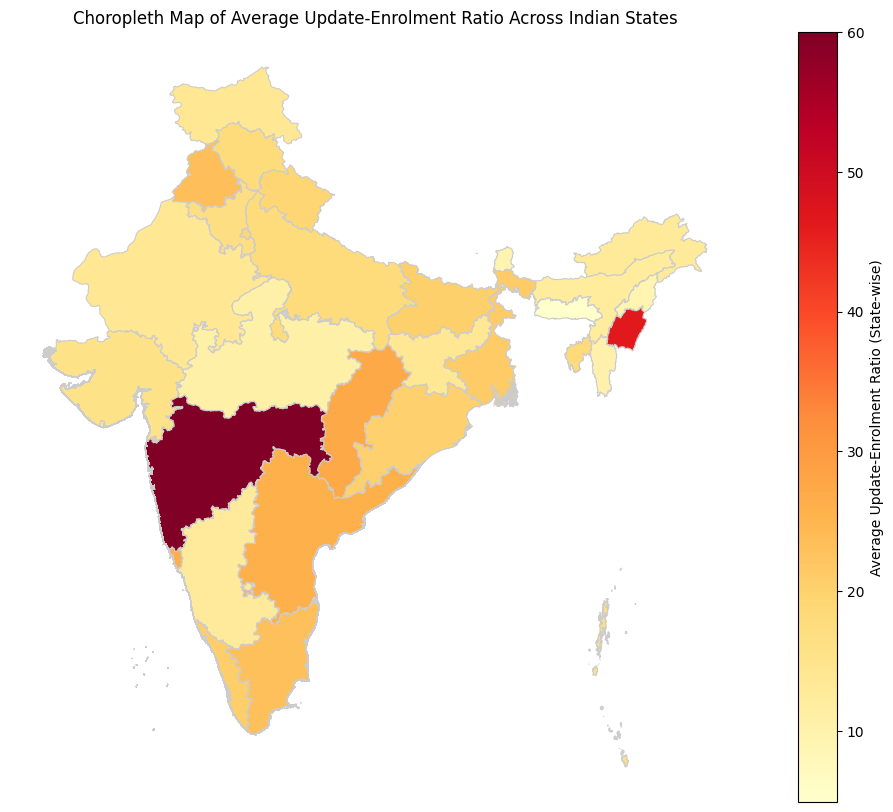

Choropleth map showing state-wise average update-enrolment ratio has been generated.


In [ ]:
import matplotlib.pyplot as plt

# Create the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged_gdf.plot(
    column='update_enrolment_ratio',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Average Update-Enrolment Ratio (State-wise)", 'orientation': "vertical"}
)

ax.set_title('Choropleth Map of Average Update-Enrolment Ratio Across Indian States')
ax.set_axis_off() # Remove axes
plt.show()

print("Choropleth map showing state-wise average update-enrolment ratio has been generated.")


## Summary:

### Data Analysis Key Findings

*   **High Update-Enrolment Ratio States**: Maharashtra shows a very high ratio, indicating a mature Aadhaar ecosystem with significant update activity. Manipur also has a relatively high ratio. States like Goa, Andhra Pradesh, Tamil Nadu, and Telangana show moderately high ratios, suggesting a transition towards update-centric operations.
*   **Low Update-Enrolment Ratio States**: States in the North-East, such as Meghalaya and Nagaland, consistently exhibit very low `update_enrolment_ratio`s, suggesting that Aadhaar enrollment in these regions might still be in an expansion phase with a higher proportion of new enrollments. Ladakh also falls into this category.
*   **Regional Patterns**: A clear gradient is observed from West/South-West to North-East India, with states in the West and South generally displaying higher update ratios, while states in the North-East show lower ratios. Northern plains and some Central Indian states show moderate ratios, indicating an intermediate stage of Aadhaar maturity.

### Insights or Next Steps

*   **Tailored Operational Strategies**: Regions with high update-enrolment ratios, such as Maharashtra, require robust infrastructure and efficient processes for handling a large volume of updates. Conversely, low-ratio regions, particularly in the North-East and Ladakh, would benefit from targeted enrolment campaigns to increase initial Aadhaar coverage.
*   **Data-Driven Policy Making**: The choropleth map serves as a valuable tool for policymakers to tailor strategies for Aadhaar services, allowing for resource allocation based on the specific needs and maturity levels of the Aadhaar ecosystem in different states.


**Q3. Are updates driven more by biometric or demographic changes?**

State-level split

In [ ]:
state_update_type = (
    df_final.groupby('state')[['bio_updates', 'demo_updates']]
    .sum()
)

state_update_type['bio_pct'] = (
    state_update_type['bio_updates'] /
    (state_update_type['bio_updates'] + state_update_type['demo_updates'])
)


In [ ]:
state_update_type.sort_values(by='bio_pct', ascending=False)

,bio_updates,demo_updates,bio_pct
state,,,
Dadra And Nagar Haveli,7958,3097,0.719855
Rajasthan,2210653,1094376,0.668876
Madhya Pradesh,2646246,1323511,0.666602
Daman And Diu,1255,647,0.659832
Andaman And Nicobar Islands,5027,2653,0.654557
Jammu And Kashmir,257220,140029,0.647503
Lakshadweep,1167,652,0.641561
Himachal Pradesh,130197,77133,0.627970
Nagaland,27660,16640,0.624379


Insight examples:

Higher biometric share → ageing population / fingerprint issues

Higher demographic share → migration / address changes

**Q4. Detect Anomalies**

Districts with extreme update spikes

In [ ]:
threshold = df_final['update_enrolment_ratio'].quantile(0.99)

anomalies = df_final[
    df_final['update_enrolment_ratio'] > threshold
][['date', 'state', 'district', 'update_enrolment_ratio']]


Certain districts exhibit anomalously high update-to-enrolment ratios, potentially indicating migration hotspots, data quality issues, or administrative bottlenecks.

In [ ]:
len(anomalies['district'].unique())

335

In [ ]:
anomalies.sort_values(by='update_enrolment_ratio', ascending=False).reset_index()[:10]

,index,date,state,district,update_enrolment_ratio
0,6312,04-11-2025,Maharashtra,Nashik,5541.000000
1,6302,04-11-2025,Maharashtra,Ahmednagar,5438.500000
2,6310,04-11-2025,Maharashtra,Nanded,3506.000000
3,6318,04-11-2025,Maharashtra,Solapur,2868.666667
4,6314,04-11-2025,Maharashtra,Parbhani,2658.000000
5,6399,04-11-2025,Tamil Nadu,Tiruvallur,2420.500000
6,6307,04-11-2025,Maharashtra,Latur,2373.500000
7,6393,04-11-2025,Tamil Nadu,Kancheepuram,2139.000000
8,6319,04-11-2025,Maharashtra,Thane,1994.666667
9,6409,04-11-2025,Telangana,Mahabubnagar,1972.500000


**Trend Analysis (Time Dimension)**

Monthly National Trend

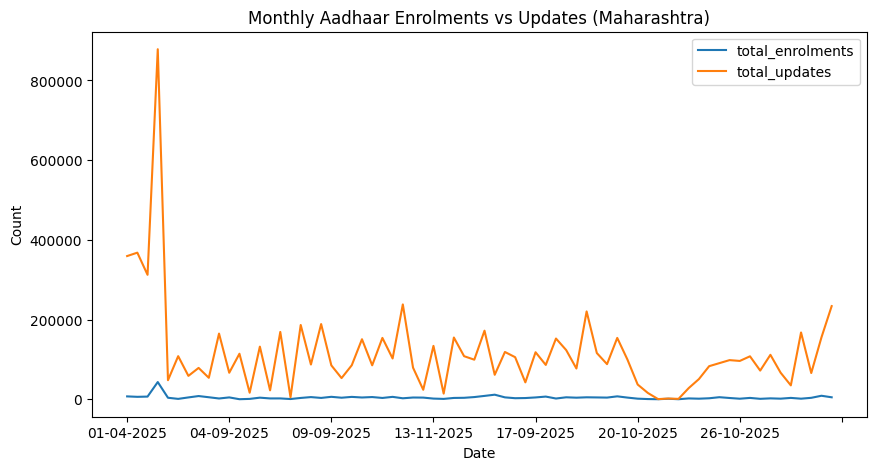

In [ ]:
import matplotlib.pyplot as plt

monthly_trend = (
    df_final[df_final['state'] == 'Maharashtra']
    .groupby('date')[['total_enrolments','total_updates']]
    .sum()
)

monthly_trend.plot(figsize=(10, 5))
plt.title("Monthly Aadhaar Enrolments vs Updates (Maharashtra)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()



**Aadhaar Lifecycle Maturity Index**

In [ ]:
df_final['aadhaar_maturity_index'] = (
    df_final['total_updates'] /
    (df_final['total_enrolments'] + df_final['total_updates'] + 1)
)


**Which districts are in expansion vs maturity phase, and how does this differ across states?**

In [ ]:
district_maturity_index = df_final.groupby(['state', 'district'])['aadhaar_maturity_index'].mean().sort_values()

low_threshold = district_maturity_index.quantile(0.33)
med_threshold = district_maturity_index.quantile(0.66)

In [ ]:
low_maturity = district_maturity_index[
    district_maturity_index < low_threshold
].reset_index(name='aadhaar_maturity_index')

high_maturity = district_maturity_index[
    district_maturity_index > med_threshold
].reset_index(name='aadhaar_maturity_index')


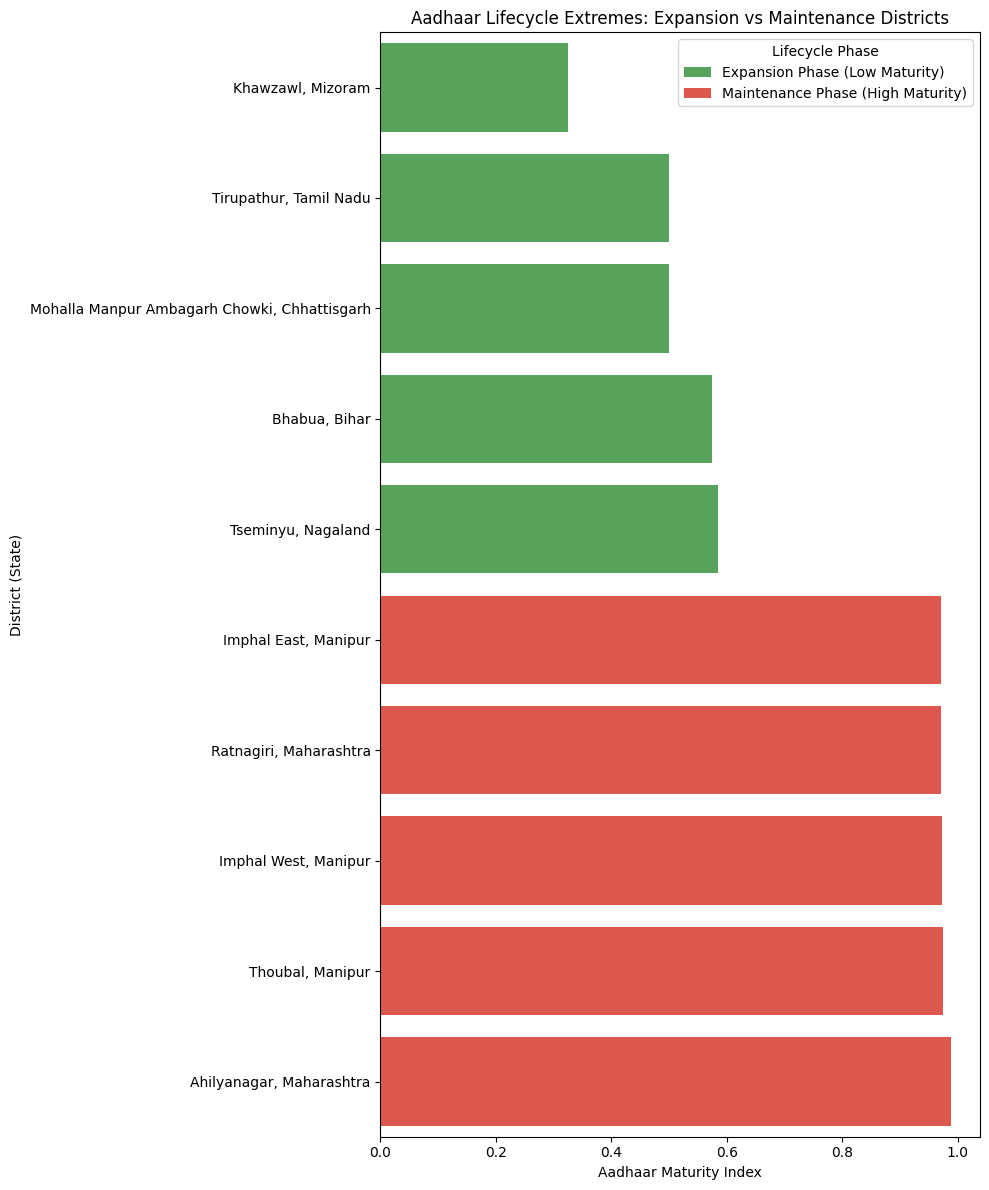

In [ ]:
# Select bottom 5 and top 5 districts by Aadhaar Maturity Index
low_maturity = low_maturity.head()

high_maturity = high_maturity.tail()

# Add category labels
low_maturity['category'] = 'Expansion Phase (Low Maturity)'
high_maturity['category'] = 'Maintenance Phase (High Maturity)'

# Combine
combined_plot = pd.concat([low_maturity, high_maturity])

# Create label
combined_plot['label'] = (
    combined_plot['district'] + ', ' + combined_plot['state']
)

# Sort for clean visual separation
combined_plot = combined_plot.sort_values('aadhaar_maturity_index')

plt.figure(figsize=(10, 12))

sns.barplot(
    data=combined_plot,
    y='label',
    x='aadhaar_maturity_index',
    hue='category',
    dodge=False,
    palette={'Expansion Phase (Low Maturity)': '#4CAF50',
             'Maintenance Phase (High Maturity)': '#F44336'}
)

plt.title('Aadhaar Lifecycle Extremes: Expansion vs Maintenance Districts')
plt.xlabel('Aadhaar Maturity Index')
plt.ylabel('District (State)')

plt.legend(title='Lifecycle Phase')
plt.tight_layout()
plt.show()


In [ ]:
low_maturity.head(10) #make a plot of it

,state,district,aadhaar_maturity_index
0,Mizoram,Khawzawl,0.325000
1,Tamil Nadu,Tirupathur,0.500000
2,Chhattisgarh,Mohalla Manpur Ambagarh Chowki,0.500000
3,Bihar,Bhabua,0.575000
4,Nagaland,Tseminyu,0.585455
5,Mizoram,Saitual,0.600000
6,Nagaland,Niuland,0.617172
7,Dadra And Nagar Haveli And Daman And Diu,Diu,0.622222
8,Meghalaya,South Garo Hills,0.630114
9,Andhra Pradesh,Mahabubnagar,0.633333


In [ ]:
high_maturity

,state,district,aadhaar_maturity_index
0,Uttar Pradesh,Sant Kabir Nagar,0.915330
1,Haryana,Bhiwani,0.915356
2,Odisha,Khordha,0.915554
3,Assam,Sribhumi,0.915587
4,Odisha,Jajapur,0.915654
...,...,...,...
295,Manipur,Imphal East,0.971044
296,Maharashtra,Ratnagiri,0.971996
297,Manipur,Imphal West,0.972661
298,Manipur,Thoubal,0.974186


**Maintenance Load Index**

In [ ]:
df_final['maintenance_load_index'] = (
    df_final['total_updates'] /
    (df_final.groupby('state')['total_updates'].transform('median') + 1)
)


Interpretation

1.5 → disproportionately high maintenance burden

Highlights stress zones, not maturity per se

In [ ]:
state_maintenance_load_index = df_final.groupby('state')['maintenance_load_index'].mean()
print("State-wise Aadhaar Maintenance Load Index:\n", state_maintenance_load_index.head(20))

State-wise Aadhaar Maintenance Load Index:
 state
Andaman And Nicobar Islands                 1.196821
Andhra Pradesh                              2.311300
Arunachal Pradesh                           1.343459
Assam                                       1.511709
Bihar                                       1.185529
Chandigarh                                  1.772114
Chhattisgarh                                1.496720
Dadra And Nagar Haveli                      1.264151
Dadra And Nagar Haveli And Daman And Diu    1.000000
Daman And Diu                               1.235065
Delhi                                       4.073197
Goa                                         0.990572
Gujarat                                     3.042283
Haryana                                     1.406353
Himachal Pradesh                            1.248991
Jammu And Kashmir                           1.415672
Jharkhand                                   1.299196
Karnataka                                   1.429

## Categorize States by Maintenance Load Index



In [ ]:
low_threshold = state_maintenance_load_index.quantile(0.33)
medium_threshold = state_maintenance_load_index.quantile(0.66)

print(f"Low threshold (33rd percentile): {low_threshold}")
print(f"Medium threshold (66th percentile): {medium_threshold}")

def categorize_maintenance_load(index_value):
    if index_value <= low_threshold:
        return 'Low'
    elif index_value <= medium_threshold:
        return 'Medium'
    else:
        return 'High'

state_maturity_category = state_maintenance_load_index.apply(categorize_maintenance_load)
print("\nState-wise Aadhaar Maintenance Load Category:\n", state_maturity_category.head(20))

Low threshold (33rd percentile): 1.260598392830365
Medium threshold (66th percentile): 1.5885909411165289

State-wise Aadhaar Maintenance Load Category:
 state
Andaman And Nicobar Islands                    Low
Andhra Pradesh                                High
Arunachal Pradesh                           Medium
Assam                                       Medium
Bihar                                          Low
Chandigarh                                    High
Chhattisgarh                                Medium
Dadra And Nagar Haveli                      Medium
Dadra And Nagar Haveli And Daman And Diu       Low
Daman And Diu                                  Low
Delhi                                         High
Goa                                            Low
Gujarat                                       High
Haryana                                     Medium
Himachal Pradesh                               Low
Jammu And Kashmir                           Medium
Jharkhand               

In [ ]:
state_maturity_df = state_maturity_category.reset_index()
state_maturity_df.rename(columns={'state': 'NAME_1', 'maintenance_load_index': 'maintenance_load_category'}, inplace=True)

# Merge with merged_gdf
merged_gdf = merged_gdf.merge(state_maturity_df, on='NAME_1', how='left')

print("Merged GeoDataFrame head after adding maintenance_load_category:")
print(merged_gdf[['NAME_1', 'update_enrolment_ratio', 'maintenance_load_category']].head())

Merged GeoDataFrame head after adding maintenance_load_category:
                        NAME_1  update_enrolment_ratio  \
0  Andaman And Nicobar Islands               16.529293   
1               Andhra Pradesh               25.830074   
2            Arunachal Pradesh               12.943406   
3                        Assam               12.430914   
4                        Bihar               20.282481   

  maintenance_load_category  
0                       Low  
1                      High  
2                    Medium  
3                    Medium  
4                       Low  


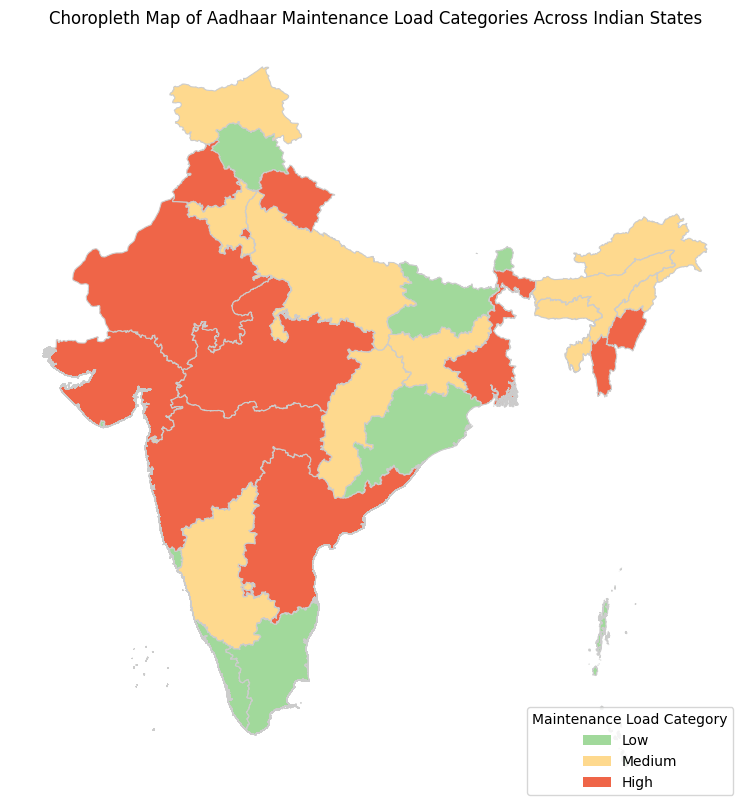

Choropleth map showing state-wise Aadhaar Maintenance Load Categories has been generated.


In [ ]:
import matplotlib.pyplot as plt

# Define a color map for the categories
category_colors = {
    'Low': '#a1d99b',    # Greenish for low load
    'Medium': '#fed98e', # Yellowish for medium load
    'High': '#ef6548'    # Reddish for high load
}

# Create the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Map categories to colors for plotting
merged_gdf['color'] = merged_gdf['maintenance_load_category'].map(category_colors)

# Plot the states using the assigned colors
merged_gdf.plot(
    color=merged_gdf['color'],
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8'
)

# Create a custom legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, fc=category_colors[category])
    for category in category_colors
]
ax.legend(legend_patches, category_colors.keys(), title="Maintenance Load Category", loc='lower right')

ax.set_title('Choropleth Map of Aadhaar Maintenance Load Categories Across Indian States')
ax.set_axis_off() # Remove axes
plt.show()

print("Choropleth map showing state-wise Aadhaar Maintenance Load Categories has been generated.")

## Summary:

### Q&A
The choropleth map visually categorizes Indian states into 'Low', 'Medium', and 'High' maintenance load for Aadhaar. States with a 'Low' maintenance load are colored greenish, 'Medium' load yellowish, and 'High' load reddish. For example, Andaman And Nicobar Islands falls into the 'Low' category, while Andhra Pradesh is in the 'High' category. The map allows for an immediate visual identification of which states require more or less attention regarding Aadhaar maintenance. Regional patterns can be observed by the clustering of similarly colored states, although specific regional patterns are not explicitly detailed in the provided output beyond individual state examples.

### Data Analysis Key Findings
*   Maintenance load categories were defined using percentiles: 'Low' for states with an index less than or equal to 1.26 (33rd percentile), 'Medium' for states with an index between 1.26 and 1.59 (up to 66th percentile), and 'High' for states with an index greater than 1.59.
*   Each state was successfully categorized into one of these three maintenance load categories (e.g., Andaman And Nicobar Islands: Low, Andhra Pradesh: High).
*   The categorical maintenance load data was successfully merged with the geographical data, preparing it for visualization.
*   A choropleth map was generated, effectively displaying the maintenance load categories across Indian states using a distinct color scheme: green for 'Low', yellow for 'Medium', and red for 'High'. The map included a clear title and a legend.

### Insights or Next Steps
*   States categorized as 'High' maintenance load should be prioritized for intervention or resource allocation to address potential issues or optimize processes.
*   Further analysis could involve exploring the underlying factors contributing to high or low maintenance loads in specific states to develop targeted strategies for improvement.


**Update Volatility Score (Detect Operational Instability)**

Stable regions have consistent update demand.

Unstable ones show spikes → migration, policy shocks, admin issues.

High volatility = unpredictable workload.

In [ ]:
district_volatility = (
    df_final.groupby(['state', 'district'])['total_updates']
    .std() /
    (df_final.groupby(['state', 'district'])['total_updates'].mean() + 1)
).reset_index(name='update_volatility')


In [ ]:
district_volatility

,state,district,update_volatility
0,Andaman And Nicobar Islands,Andamans,0.483918
1,Andaman And Nicobar Islands,Nicobar,0.674374
2,Andaman And Nicobar Islands,North And Middle Andaman,0.468537
3,Andaman And Nicobar Islands,South Andaman,0.351581
4,Andhra Pradesh,Adilabad,0.463027
...,...,...,...
877,West Bengal,South 24 Parganas,0.530885
878,West Bengal,South Dinajpur,0.527170
879,West Bengal,South Twenty Four Parganas,0.463691
880,West Bengal,Uttar Dinajpur,1.213289


Which districts exhibit unstable Aadhaar demand, and may require flexible or mobile infrastructure?



In [ ]:
dist_vola = district_volatility.sort_values(by='update_volatility', ascending=False)[:15]

In [ ]:
dist_vola

,state,district,update_volatility
450,Madhya Pradesh,Shivpuri,3.820803
208,Delhi,Shahdara,3.719244
417,Madhya Pradesh,Guna,3.441792
445,Madhya Pradesh,Sehore,3.379611
449,Madhya Pradesh,Sheopur,3.360382
270,Haryana,Panipat,3.329281
156,Chandigarh,Chandigarh,3.325776
251,Gujarat,The Dangs,3.300523
402,Madhya Pradesh,Ashok Nagar,3.278886
408,Madhya Pradesh,Burhanpur,3.246515


/tmp/ipython-input-245900920.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


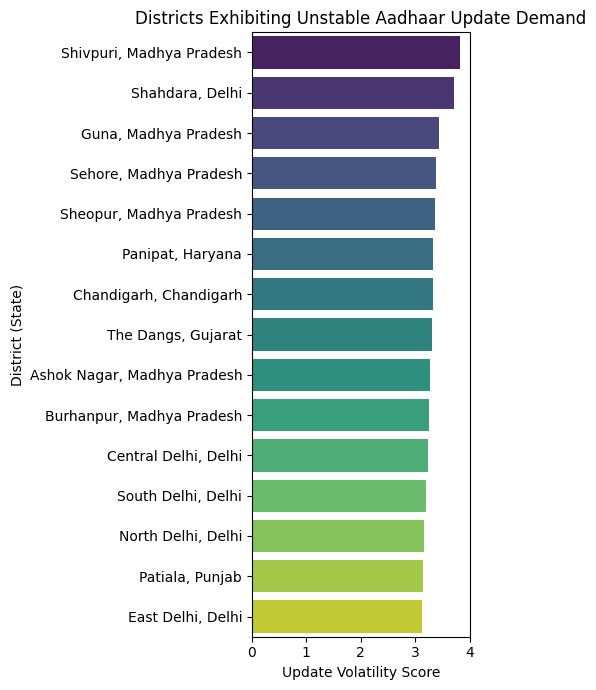

In [ ]:
dist_vola_plot = dist_vola.copy()
dist_vola_plot['label'] = (
    dist_vola_plot['district'] + ', ' + dist_vola_plot['state']
)

# Sort by volatility (descending)
dist_vola_plot = dist_vola_plot.sort_values(
    by='update_volatility',
    ascending=False
)

plt.figure(figsize=(5, 7))

sns.barplot(
    data=dist_vola_plot,
    y='label',
    x='update_volatility',
    palette='viridis'
)

plt.title('Districts Exhibiting Unstable Aadhaar Update Demand')
plt.xlabel('Update Volatility Score')
plt.ylabel('District (State)')

plt.tight_layout()
plt.show()

**Child-to-Adult Enrolment Skew Index**

High child enrolment suggests:

Population growth

Awareness campaigns

School-based drives



In [ ]:
df_final['child_enrolment_ratio'] = (
    df_final['age_0_5'] + df_final['age_5_17']
) / (df_final['total_enrolments'] + 1)


**Are certain states/districts showing demographic skew in Aadhaar enrolment?**

High child skew → future update burden (biometrics change with age)

Planning long-term Aadhaar refresh cycles

In [ ]:
child_adult_skew = (df_final.groupby('state')['child_enrolment_ratio'].mean().sort_values(ascending=False))
child_adult_skew

,child_enrolment_ratio
state,
Uttar Pradesh,0.957300
Tamil Nadu,0.943471
Chandigarh,0.943260
Haryana,0.942539
Rajasthan,0.939732
Madhya Pradesh,0.935337
Bihar,0.934734
Maharashtra,0.934230
Odisha,0.933711


In [ ]:
child_adult_skew_district = (df_final.groupby(['state','district'])['child_enrolment_ratio'].mean().sort_values(ascending=False))
child_adult_skew_district.head(10)

state           district   
West Bengal     Bardhaman      0.990846
Uttar Pradesh   Bijnor         0.987720
West Bengal     Murshidabad    0.986560
Telangana       Medak          0.985780
Karnataka       Bangalore      0.984885
Madhya Pradesh  Rewa           0.983781
Tamil Nadu      Madurai        0.983638
                Villupuram     0.982658
Uttar Pradesh   Meerut         0.982482
Tamil Nadu      Tiruvallur     0.981182
Name: child_enrolment_ratio, dtype: float64

**Biometric Fragility Index**

Some regions require frequent biometric updates due to:

Manual labor

Aging population

Environmental factors

In [ ]:
df_final['biometric_fragility'] = (
    df_final['bio_updates'] /
    (df_final['total_updates'] + 1)
)


**Which regions face biometric instability, indicating need for alternate authentication or relaxed biometric policies?**

In [ ]:
bio_fragile_states = df_final.groupby('state')['biometric_fragility'].mean().sort_values(ascending=False)
bio_fragile_states

,biometric_fragility
state,
Dadra And Nagar Haveli,0.663755
Jammu And Kashmir,0.611421
Lakshadweep,0.611065
Andaman And Nicobar Islands,0.607421
Puducherry,0.598261
Himachal Pradesh,0.594243
Daman And Diu,0.579563
Haryana,0.571750
Maharashtra,0.568727


In [ ]:
bio_fragile_district = df_final.groupby(['state','district'])['biometric_fragility'].mean().sort_values(ascending=False)
bio_fragile_district.head(10)

state              district                
Nagaland           Meluri                      0.856351
Chhattisgarh       Dantewada                   0.780530
Maharashtra        Nandurbar                   0.760900
                   Wardha                      0.735377
Madhya Pradesh     Hoshangabad                 0.731517
Jammu And Kashmir  Ramban                      0.727353
Madhya Pradesh     Burhanpur                   0.720275
                   Harda                       0.715735
Telangana          Medchal−Malkajgiri          0.712469
Chhattisgarh       Dakshin Bastar Dantewada    0.706975
Name: biometric_fragility, dtype: float64

**Do mature Aadhaar regions show declining enrolments over time?**

Ans - No. See the trend of enrollment in maharashtra ... it is pretty uniform

In [ ]:
corr_features = df_final[[
    'update_enrolment_ratio',
    'maintenance_load_index',
    'biometric_fragility',
    'child_enrolment_ratio',
    'aadhaar_maturity_index'
]]


In [ ]:
corr_matrix = corr_features.corr(method='spearman')

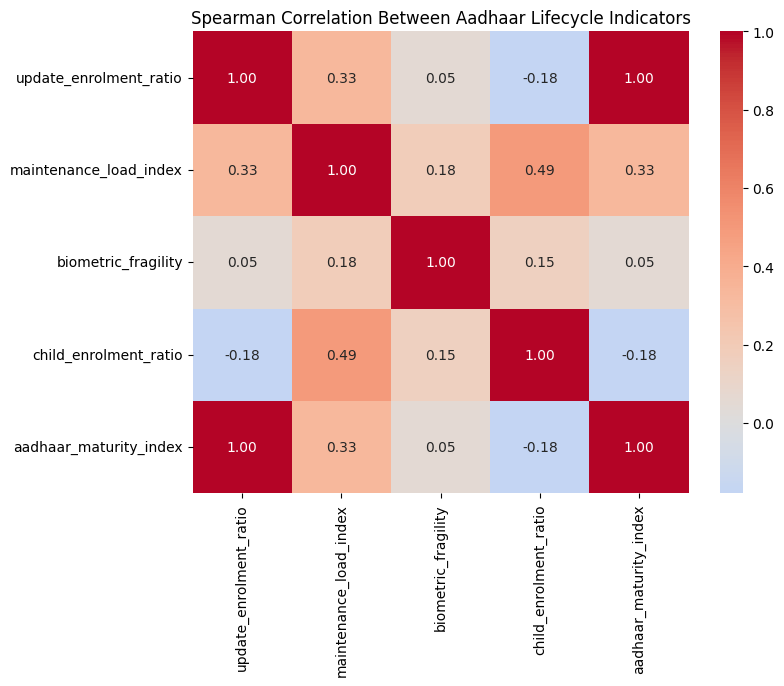

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)
plt.title("Spearman Correlation Between Aadhaar Lifecycle Indicators")
plt.show()

##Update–Enrolment Ratio ≡ Aadhaar Maturity (ρ ≈ 1.0)

This very strong relationship confirms that Aadhaar maturity is primarily defined by how update-driven a region is. In areas where Aadhaar has already reached most of the population, the system naturally shifts from enrolling new users to maintaining and correcting existing records. This shows that Aadhaar has moved beyond an expansion phase in most regions and is now operating as a long-term identity infrastructure.

##Maintenance Load shows only moderate linkage to maturity (ρ ≈ 0.33)

Although mature Aadhaar regions are update-heavy, they do not automatically experience high operational stress. This indicates that maintenance load depends on additional factors such as administrative efficiency, demographic composition, and local demand patterns. In practical terms, some mature states handle updates smoothly, while others struggle, highlighting the need for targeted resource planning rather than uniform scaling.

##Child Enrolment strongly predicts Maintenance Load (ρ ≈ 0.49)

This is the most important relationship in the analysis. Regions enrolling a higher share of children tend to experience significantly higher Aadhaar maintenance demand. Since children require frequent biometric and demographic updates as they grow, early-stage enrolment creates a long-term service obligation. This makes child enrolment a powerful early indicator of future Aadhaar workload.

##Child Enrolment is weakly negative with Update–Enrolment Ratio (ρ ≈ −0.18)

Areas with high child enrolment often appear less update-heavy in the short term because new registrations dominate activity. However, this temporarily masks the future update burden that will emerge as these children age. In other words, regions in an apparent expansion phase today are likely to transition into high-maintenance regions tomorrow.

##Biometric Fragility remains weakly correlated across all indices (ρ < 0.2)

The weak correlations involving biometric fragility suggest that biometric issues are not simply a consequence of high enrolment or update volumes. Instead, they are likely driven by localized factors such as occupation, age profiles, or environmental conditions. This implies that biometric challenges should be addressed through targeted technical or policy interventions, rather than broad system-wide changes.

##Overall Interpretation (Plain Language)

Together, these relationships show that Aadhaar system pressure is not determined by scale alone. Who is being enrolled matters as much as how many are enrolled. Demographic composition—especially child enrolment—emerges as the strongest predictor of future maintenance demand, while biometric challenges remain a separate, localized concern. This highlights the importance of anticipatory planning over reactive system expansion.

In [ ]:
state_month = (
    df_final
    .groupby(['state', 'date'])
    .agg({
        'update_enrolment_ratio': 'mean',
        'aadhaar_maturity_index': 'mean',
        'maintenance_load_index': 'mean',
        'biometric_fragility': 'mean',
        'child_enrolment_ratio': 'mean'
    })
    .reset_index()
)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

metrics = [
    'update_enrolment_ratio',
    'aadhaar_maturity_index',
    'maintenance_load_index',
    'biometric_fragility',
    'child_enrolment_ratio'
]

scaler = MinMaxScaler()

state_month_scaled = state_month.copy()
state_month_scaled[metrics] = scaler.fit_transform(state_month[metrics])


In [ ]:
state_month_long = state_month_scaled.melt(
    id_vars=['state', 'date'],
    value_vars=metrics,
    var_name='metric',
    value_name='normalized_value'
)


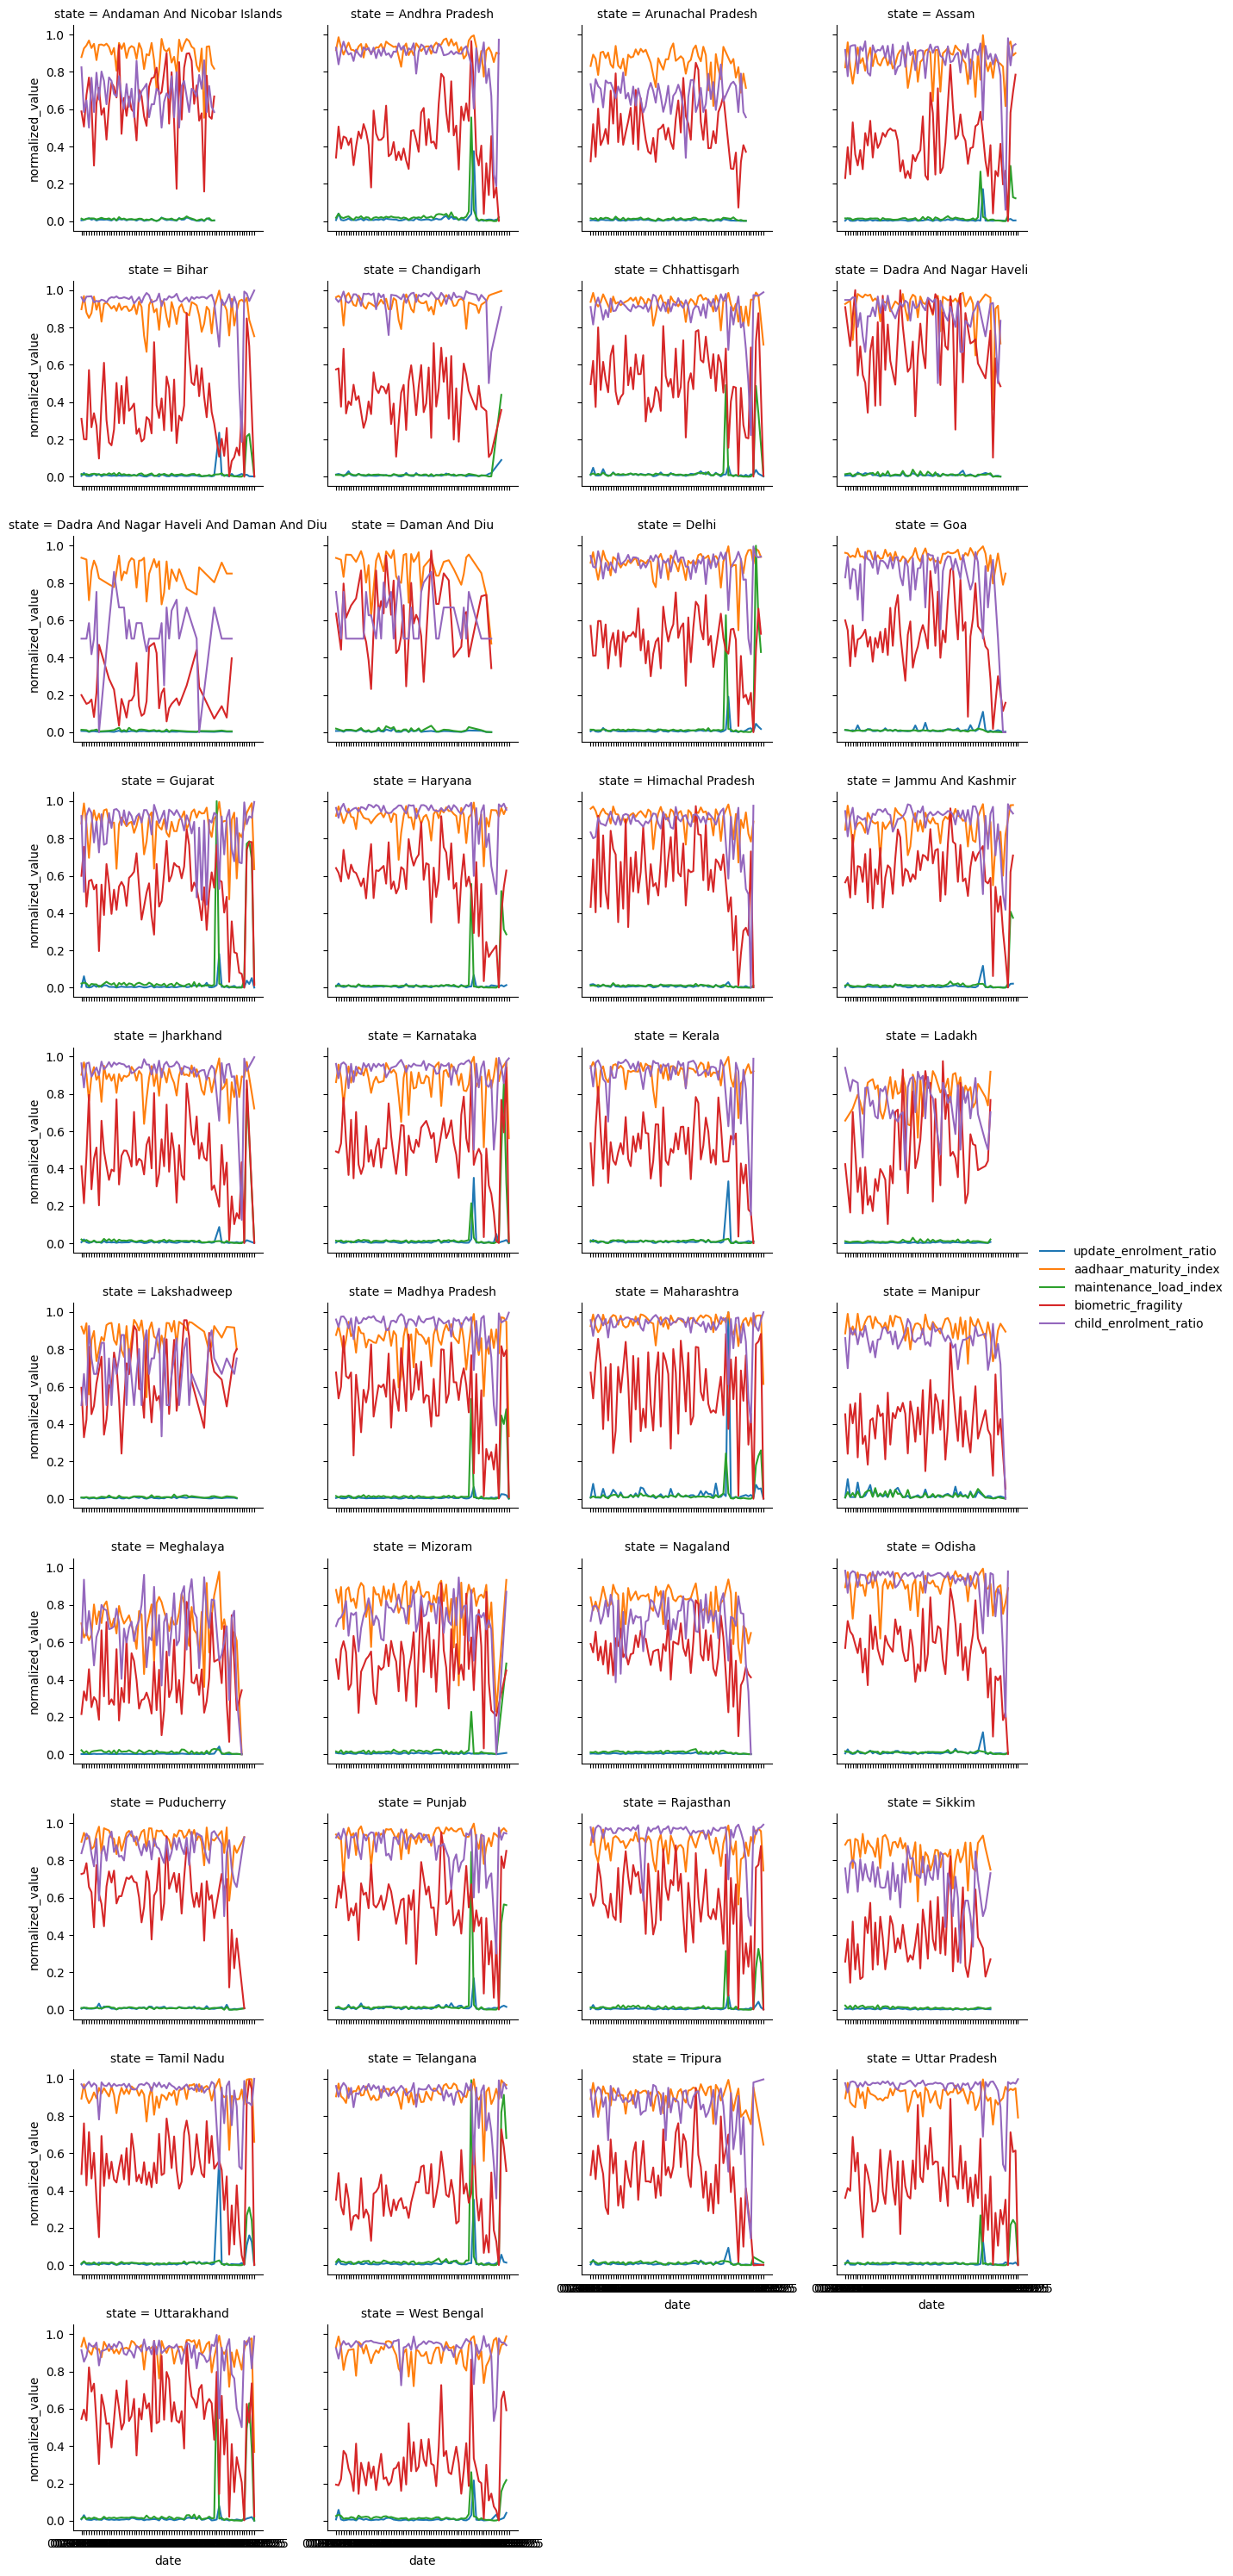

In [ ]:
g = sns.FacetGrid(
    state_month_long,
    col="state",
    col_wrap=4,
    height=3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x='date',
    y='normalized_value',
    hue='metric'
)

g.add_legend()
plt.show()


## Executive Summary: Aadhaar System Lifecycle and Operational Dynamics

This analysis explores various facets of the Aadhaar ecosystem across India, identifying key trends, regional disparities, and critical drivers impacting its operational demands. Below are the executive summary points:

1.  **Aadhaar System Maturity Varies Significantly**: The `update_enrolment_ratio` serves as a primary indicator of Aadhaar system maturity. States like Maharashtra and Manipur show high ratios, signifying mature systems focused on updates, while regions like Meghalaya and Ladakh exhibit low ratios, indicating an ongoing expansion phase with a focus on new enrolments.

2.  **Pronounced Localized Variations**: District-level analysis reveals even more extreme disparities than state averages. Certain districts within high-performing states (e.g., Ahmednagar, Nashik in Maharashtra) demonstrate exceptionally high update-to-enrolment ratios, suggesting intensive update campaigns or mature penetration. Conversely, some districts are still in early expansion stages.

3.  **Update Types Reflect Regional Needs**: An inverse relationship generally exists between biometric and demographic updates. Regions with a high `bio_share` (e.g., Dadra and Nagar Haveli, J&K) likely focus on biometric accuracy due to aging populations or specific initiatives, while areas with high `demo_share` (e.g., West Bengal, Bihar) face more demographic data corrections, possibly driven by migration or administrative changes.

4.  **Maintenance Load is Diverse**: The `Maintenance Load Index` categorizes states into low, medium, and high burdens. High-load states like Andhra Pradesh and Delhi require robust infrastructure and efficient processes, while low-load states might need continued enrolment drives. This highlights that maturity alone does not predict operational stress; administrative efficiency and local factors play a crucial role.

5.  **Child Enrolment is a Critical Future Predictor**: A strong positive correlation exists between `child_enrolment_ratio` and `maintenance_load_index`. Regions with higher child enrolments are expected to face significantly increased future maintenance demands, as children require frequent biometric and demographic updates as they grow. This indicates that current expansion phases in child enrolment areas will translate into higher update burdens later.

6.  **Biometric Fragility Requires Targeted Solutions**: `Biometric fragility` shows weak correlation with overall update volumes, suggesting that biometric challenges are primarily driven by localized factors such as occupation, environmental conditions, or aging populations. These issues demand specific technical or policy interventions rather than broad system-wide changes.

7.  **Anomalies and Volatility Exist**: Certain districts exhibit anomalously high update spikes or high volatility in update demand (e.g., Shivpuri in Madhya Pradesh, Shahdara in Delhi). These anomalies can indicate migration hotspots, data quality issues, or administrative bottlenecks, necessitating flexible or mobile infrastructure solutions.